# Matrix Spike (MS) Per-Analyte Time-Series Analysis

## Purpose

This notebook explores the historical time-series behaviour of Matrix Spike (MS)
QC results.

The aim is to:

- visualise Matrix Spike results through time;
- examine behaviour separately for different analytes;
- retain relevant analytical context such as Scheme and Unit;
- compare historical MS results with the existing CCLAS target and limits;
- show where existing CCLAS classifications occur;
- identify descriptive differences in historical behaviour between analytes;
- provide historical context for the subsequent drift-detection task.

This notebook is exploratory and descriptive only.

It does not create new anomaly or drift classifications.

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Matrix Spike Data

In [23]:
from pathlib import Path

# Search the repository for the QC Anomaly Training Data workbook
search_locations = [
    Path("."),
    Path("..")
]

matches = []

for location in search_locations:
    matches.extend(
        location.rglob("QC Anomaly Training Data*.xlsx")
    )

# Remove duplicate paths
matches = list(dict.fromkeys(matches))

if len(matches) == 0:
    raise FileNotFoundError(
        "Could not find a QC Anomaly Training Data Excel workbook."
    )

print("Matching files found:")
for i, file in enumerate(matches):
    print(i, file)

data_file = matches[0]

print("\nUsing file:", data_file)

Matching files found:
0 ../data/raw/QC Anomaly Training Data v2 (1).xlsx

Using file: ../data/raw/QC Anomaly Training Data v2 (1).xlsx


In [24]:
ms = pd.read_excel(
    data_file,
    sheet_name="SPK(MS) Assessment"
)

# Remove completely empty columns
ms = ms.dropna(axis=1, how="all")

print("Matrix Spike rows:", len(ms))
print("Useful columns:", len(ms.columns))

display(ms.head())

Matrix Spike rows: 6958
Useful columns: 25


,ANALYTICAL_TYPE,QC_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,...,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,UNIT_CODE,SPECIFICATION_CODE
0,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0010007372,0.093486,2021-06-08 16:35:31,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
1,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0009017856,0.100020,2021-05-10 15:11:04,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
2,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0009017856,0.103217,2021-05-07 12:18:32,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
3,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0009017856,0.062144,2021-05-05 10:31:07,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
4,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0006998356,0.091200,2021-03-03 13:04:39,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C


## 3. Matrix Spike Dataset Structure

The available Matrix Spike fields are reviewed before preparing the time-series analysis.

In [25]:
print("Dataset shape:", ms.shape)

print("\nColumns:")
for column in ms.columns:
    print("-", column)

print("\nQC type values:")
print(ms["QC_TYPE"].value_counts(dropna=False))

print("\nUnique analytes:", ms["ANALYTE_CODE"].nunique())
print("Unique schemes:", ms["SCHEME_CODE"].nunique())
print("Unique units:", ms["UNIT_CODE"].nunique())

ms["ANALYSED_DATE"] = pd.to_datetime(
    ms["ANALYSED_DATE"],
    errors="coerce"
)

print(
    "\nDate range:",
    ms["ANALYSED_DATE"].min(),
    "to",
    ms["ANALYSED_DATE"].max()
)

Dataset shape: (6958, 25)

Columns:
- ANALYTICAL_TYPE
- QC_TYPE
- STD_LOT_CODE
- STD_CODE
- JOB_CODE
- NUMERIC_FINAL_VALUE
- ANALYSED_DATE
- SCHEME_CODE
- ANALYTE_CODE
- STANDARD_STATUS
- INTERNAL_MIN_VALUE
- INTERNAL_MAX_VALUE
- INTERNAL_MIN_INCLUSIVE
- INTERNAL_MAX_INCLUSIVE
- INTERNAL_MAX_WARNING_VALUE
- INTERNAL_MIN_WARNING_VALUE
- INTERNAL_MIN_WARNING_INCLUSIVE
- INTERNAL_MAX_WARNING_INCLUSIVE
- LIM_REP_VALUE
- STAT_DL_VALUE
- LIM_REP_DUP_VALUE
- STAT_DL_DUP_VALUE
- INTERNAL_TARGET_VALUE
- UNIT_CODE
- SPECIFICATION_CODE

QC type values:
QC_TYPE
MS    6958
Name: count, dtype: int64

Unique analytes: 57
Unique schemes: 2
Unique units: 2

Date range: 2020-06-26 04:23:55 to 2021-11-10 07:12:48


## 4. Prepare Matrix Spike Time-Series Data

The Matrix Spike records are prepared for historical time-series visualisation.

The analysis retains the analytical context, measured result, existing CCLAS
target and limits, and existing CCLAS status.

Rows missing the minimum information required for time-series plotting are
excluded from the plotting dataset only.

In [26]:
time_series_columns = [
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "ANALYSED_DATE",
    "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE",
    "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_MAX_WARNING_VALUE",
    "INTERNAL_MIN_VALUE",
    "INTERNAL_MAX_VALUE",
    "STANDARD_STATUS"
]

# Check that all required fields exist
missing_columns = [
    column
    for column in time_series_columns
    if column not in ms.columns
]

if missing_columns:
    raise ValueError(
        f"Required time-series columns are missing: {missing_columns}"
    )

# Create a separate dataset for the time-series analysis
ms_time = ms[time_series_columns].copy()

# Ensure date is stored correctly
ms_time["ANALYSED_DATE"] = pd.to_datetime(
    ms_time["ANALYSED_DATE"],
    errors="coerce"
)

# Remove only rows that cannot be plotted meaningfully
ms_time = ms_time.dropna(
    subset=[
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
        "NUMERIC_FINAL_VALUE"
    ]
)

# Put observations into historical order
ms_time = ms_time.sort_values("ANALYSED_DATE")

print("Original MS rows:", len(ms))
print("Usable time-series rows:", len(ms_time))
print("Rows excluded from plotting:", len(ms) - len(ms_time))

print(
    "\nTime-series date range:",
    ms_time["ANALYSED_DATE"].min(),
    "to",
    ms_time["ANALYSED_DATE"].max()
)

display(ms_time.head())

Original MS rows: 6958
Usable time-series rows: 6872
Rows excluded from plotting: 86

Time-series date range: 2020-06-26 04:23:55 to 2021-11-10 07:12:48


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,STANDARD_STATUS
2652,GE_IMS40Q12,SE,MG_KG,2020-06-26 04:23:55,3.618605,3.40,0.012920,6.787080,-1.940040,8.740040,Pass
3757,GE_IMS40Q12,SB,MG_KG,2020-06-26 04:23:55,6.725581,6.37,5.886517,6.853483,5.608148,7.131852,Pass
977,GE_IMS40Q12,BI,MG_KG,2020-06-26 04:23:55,0.667907,0.67,0.564073,0.775927,0.502969,0.837031,Pass
620,GE_IMS40Q12,TE,MG_KG,2020-06-26 04:23:55,0.513488,0.46,0.351532,0.568468,0.289018,0.630982,Pass
5240,GE_IMS40Q12,AS,MG_KG,2020-06-26 04:23:55,60.744186,57.00,53.067000,60.933000,50.798400,63.201600,Pass


## 5. Calculate Deviation from the CCLAS Target

For each Matrix Spike result, deviation is calculated as the difference between
the measured result and the existing CCLAS target.

A deviation of zero represents the target value.
Positive deviations are above the target and negative deviations are below it.

The existing CCLAS warning and failure limits are also converted to the same
deviation-from-target scale so they can be overlaid on the time-series plots.

In [27]:
# Calculate deviation from the existing CCLAS target
ms_time["DEVIATION"] = (
    ms_time["NUMERIC_FINAL_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

# Convert existing warning/failure bounds into deviation-from-target bounds
ms_time["LOWER_WARNING_DEVIATION"] = (
    ms_time["INTERNAL_MIN_WARNING_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

ms_time["UPPER_WARNING_DEVIATION"] = (
    ms_time["INTERNAL_MAX_WARNING_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

ms_time["LOWER_FAILURE_DEVIATION"] = (
    ms_time["INTERNAL_MIN_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

ms_time["UPPER_FAILURE_DEVIATION"] = (
    ms_time["INTERNAL_MAX_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

display(
    ms_time[
        [
            "ANALYTE_CODE",
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "INTERNAL_TARGET_VALUE",
            "DEVIATION",
            "STANDARD_STATUS"
        ]
    ].head()
)

,ANALYTE_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,DEVIATION,STANDARD_STATUS
2652,SE,2020-06-26 04:23:55,3.618605,3.40,0.218605,Pass
3757,SB,2020-06-26 04:23:55,6.725581,6.37,0.355581,Pass
977,BI,2020-06-26 04:23:55,0.667907,0.67,-0.002093,Pass
620,TE,2020-06-26 04:23:55,0.513488,0.46,0.053488,Pass
5240,AS,2020-06-26 04:23:55,60.744186,57.00,3.744186,Pass


## 6. Per-Analyte Matrix Spike Time-Series Visualisations

Each plot shows Matrix Spike deviation from the supplied target through time
for one Scheme–Analyte–Unit group.

Points are coloured using the existing CCLAS STANDARD_STATUS classification.

The plots also include the existing warning and failure boundaries converted
to the same deviation-from-target scale.

These visualisations describe historical behaviour only and do not assign
new anomaly or drift classifications.

In [28]:
status_colours = {
    "Pass": "green",
    "UpperWarning": "orange",
    "LowerWarning": "orange",
    "UpperFailure": "red",
    "LowerFailure": "red",
    "IgnoredUpperFailure": "purple",
    "IgnoredLowerFailure": "purple",
    "NotTested": "gray"
}

In [29]:
def plot_ms_deviation(data, scheme, analyte, unit):

    group = data[
        (data["SCHEME_CODE"] == scheme) &
        (data["ANALYTE_CODE"] == analyte) &
        (data["UNIT_CODE"] == unit)
    ].copy()

    group = group.sort_values("ANALYSED_DATE")

    if group.empty:
        return

    plt.figure(figsize=(13, 6))

    # Plot points coloured by existing CCLAS status
    for status in group["STANDARD_STATUS"].dropna().unique():

        status_data = group[
            group["STANDARD_STATUS"] == status
        ]

        plt.scatter(
            status_data["ANALYSED_DATE"],
            status_data["DEVIATION"],
            color=status_colours.get(status, "gray"),
            label=status,
            alpha=0.7,
            s=25
        )

    # Target = zero deviation
    plt.axhline(
        0,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label="Target"
    )

    # Existing CCLAS warning limits
    plt.plot(
        group["ANALYSED_DATE"],
        group["LOWER_WARNING_DEVIATION"],
        color="orange",
        linestyle="--",
        label="Lower Warning"
    )

    plt.plot(
        group["ANALYSED_DATE"],
        group["UPPER_WARNING_DEVIATION"],
        color="orange",
        linestyle="--",
        label="Upper Warning"
    )

    # Existing CCLAS failure limits
    plt.plot(
        group["ANALYSED_DATE"],
        group["LOWER_FAILURE_DEVIATION"],
        color="red",
        linestyle=":",
        label="Lower Failure"
    )

    plt.plot(
        group["ANALYSED_DATE"],
        group["UPPER_FAILURE_DEVIATION"],
        color="red",
        linestyle=":",
        label="Upper Failure"
    )

    plt.title(
        f"Matrix Spike Deviation Over Time - "
        f"{analyte} | {scheme} | {unit}"
    )

    plt.xlabel("Analysed Date")
    plt.ylabel("Deviation from Target")

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

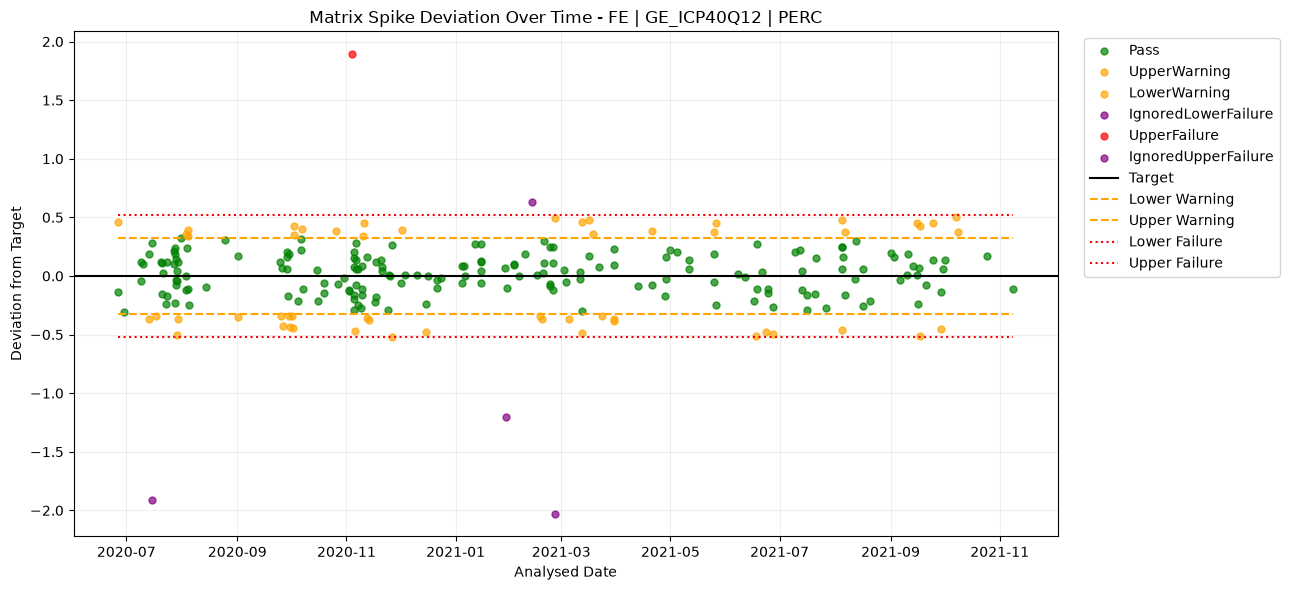

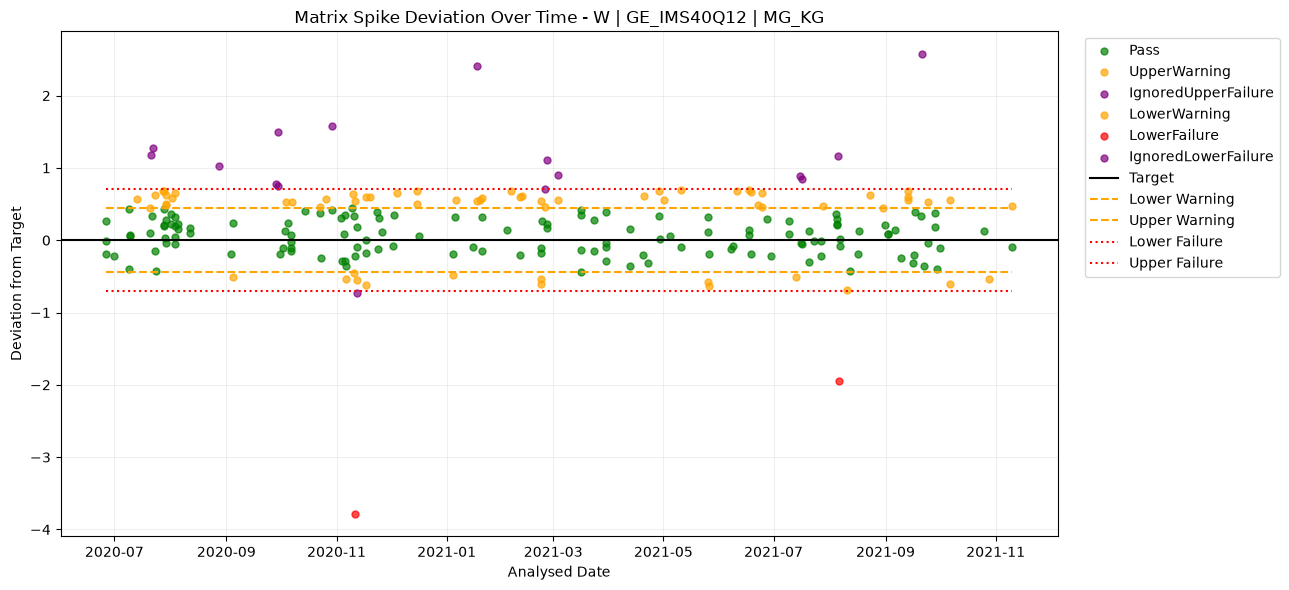

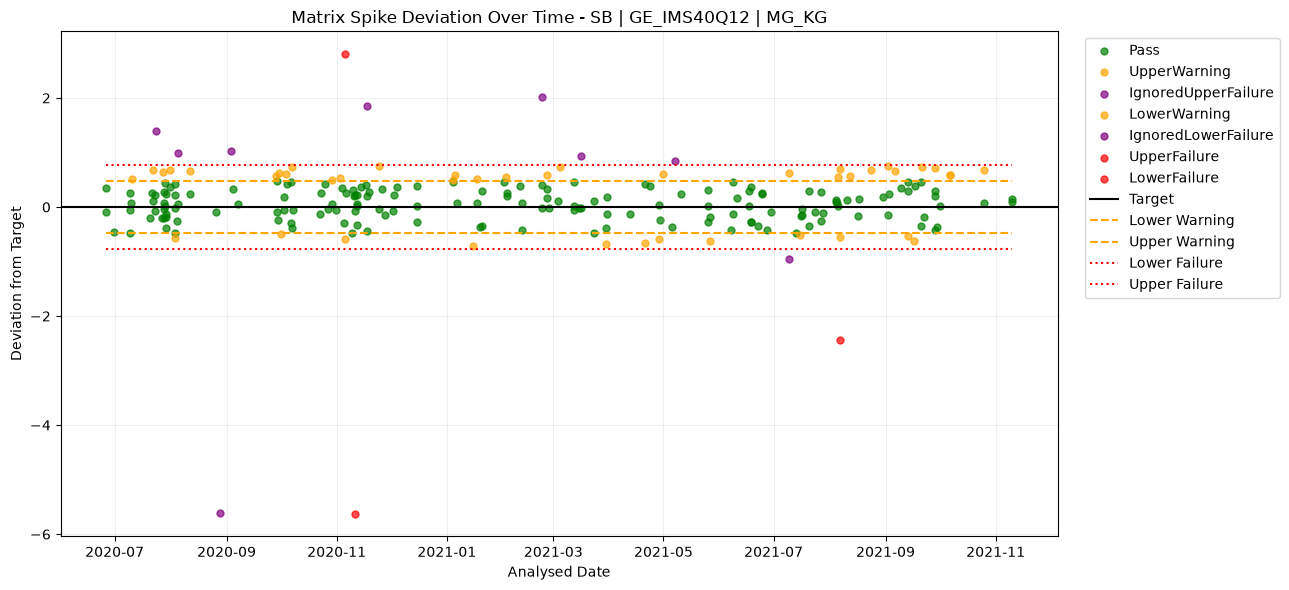

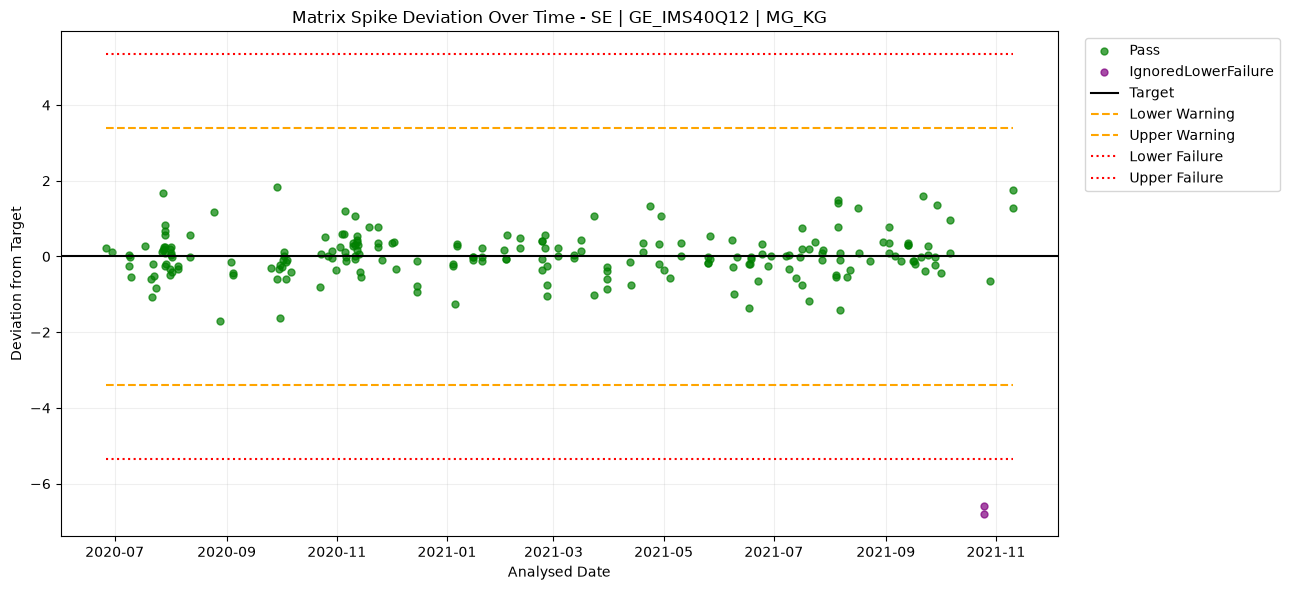

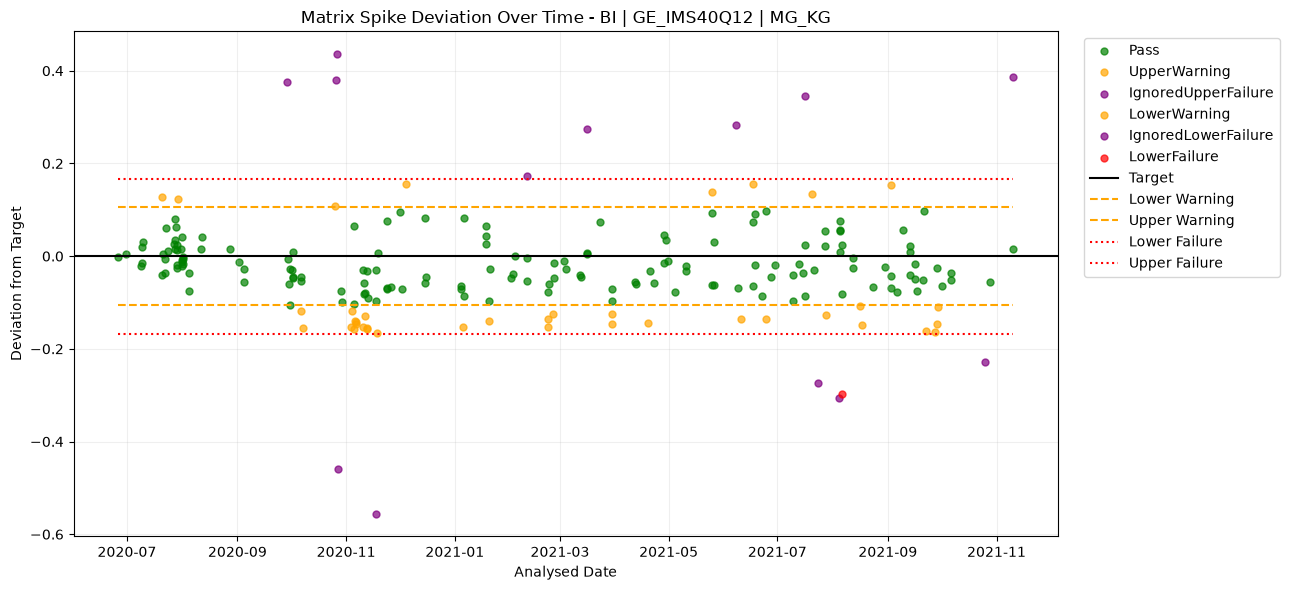

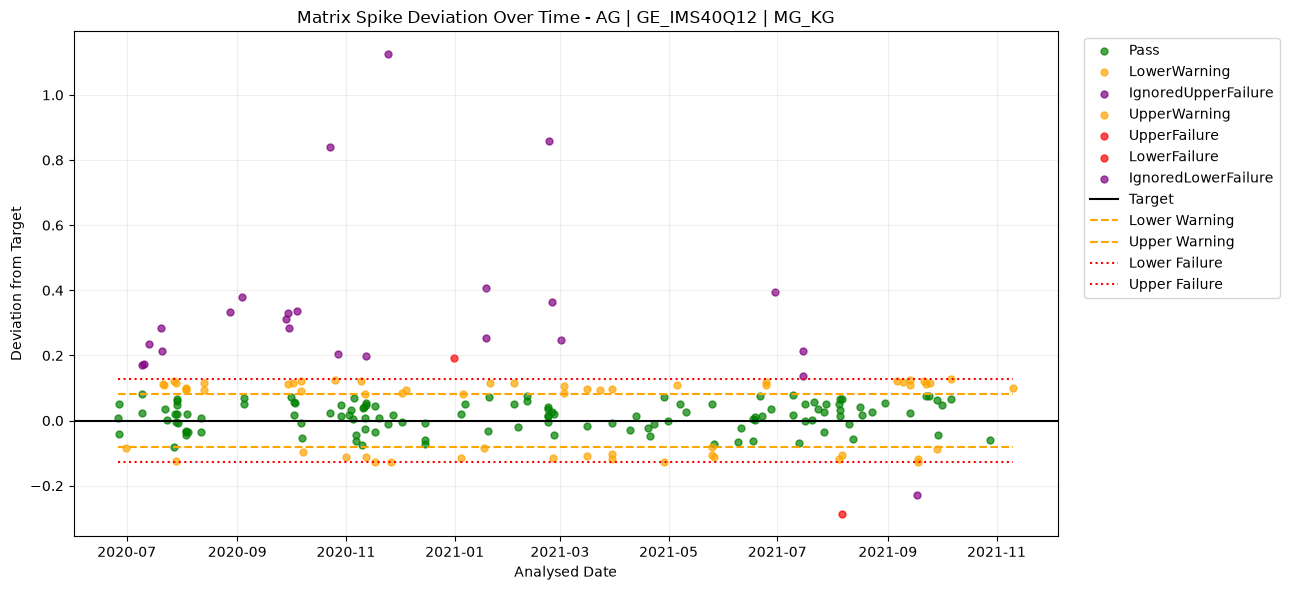

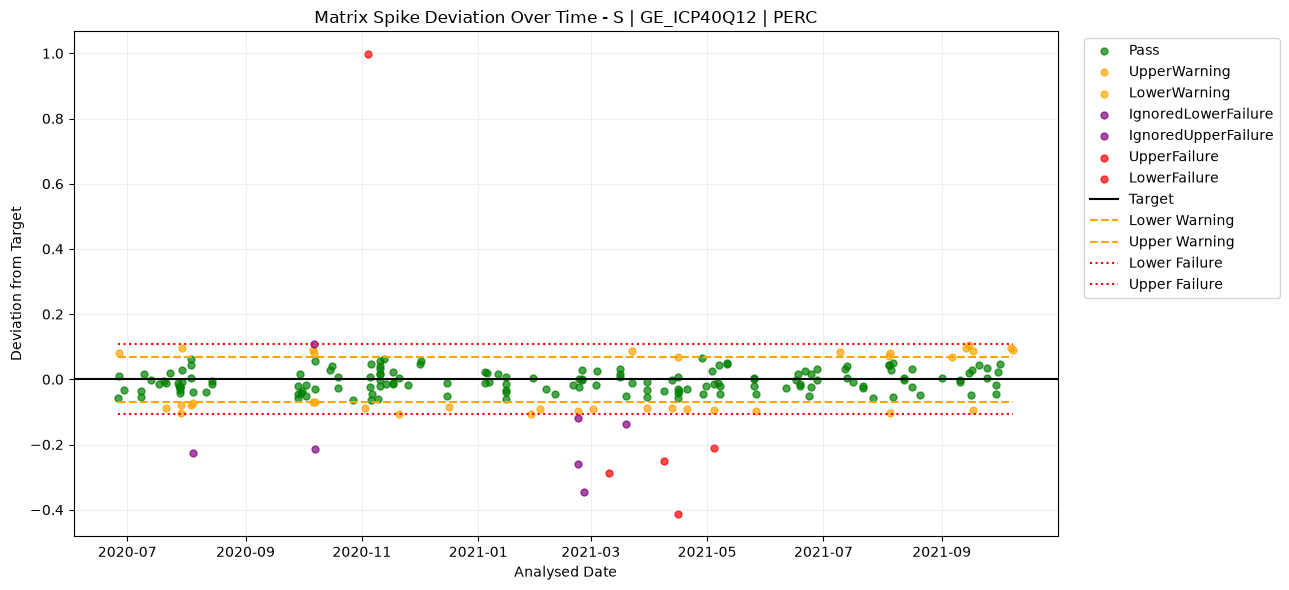

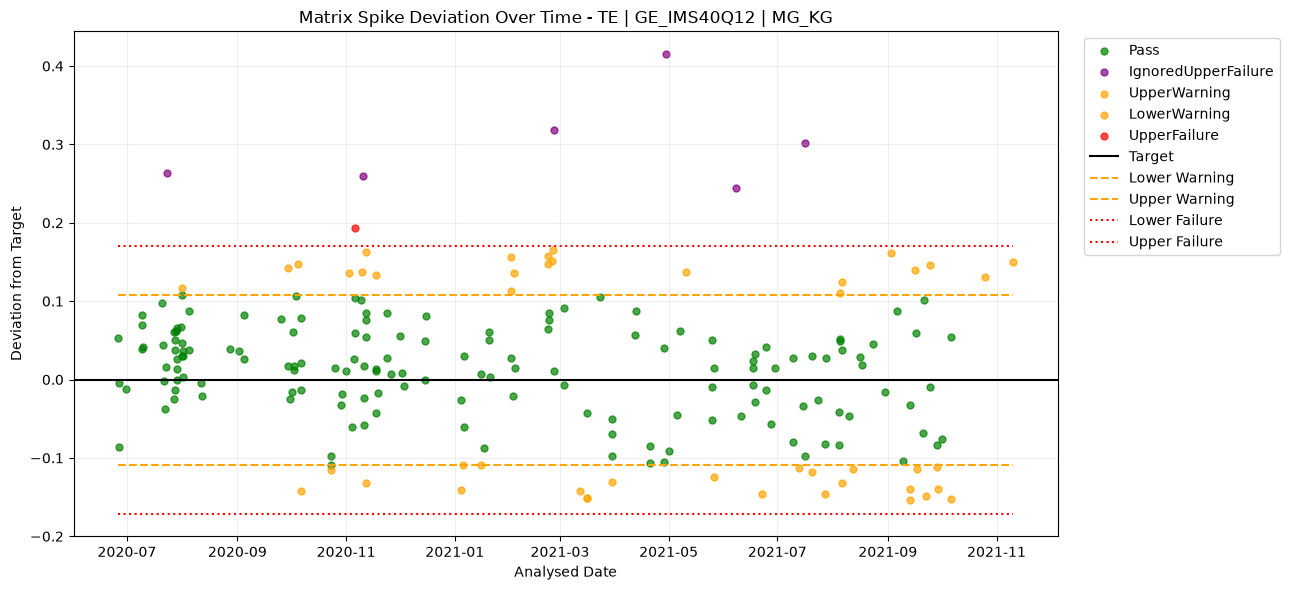

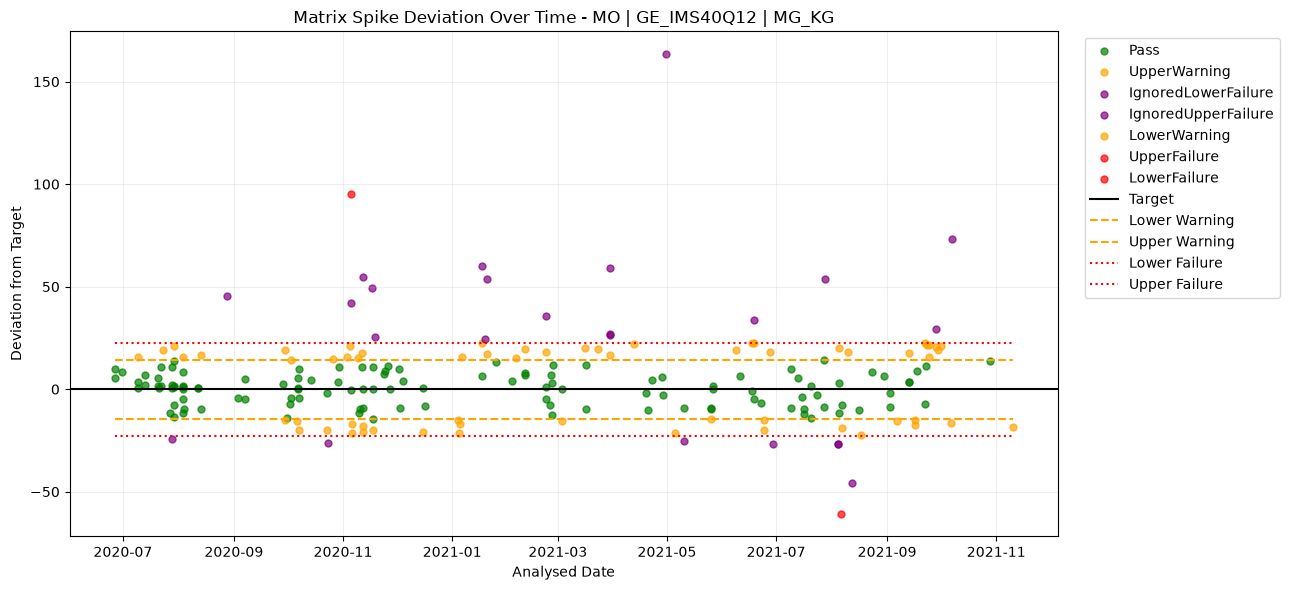

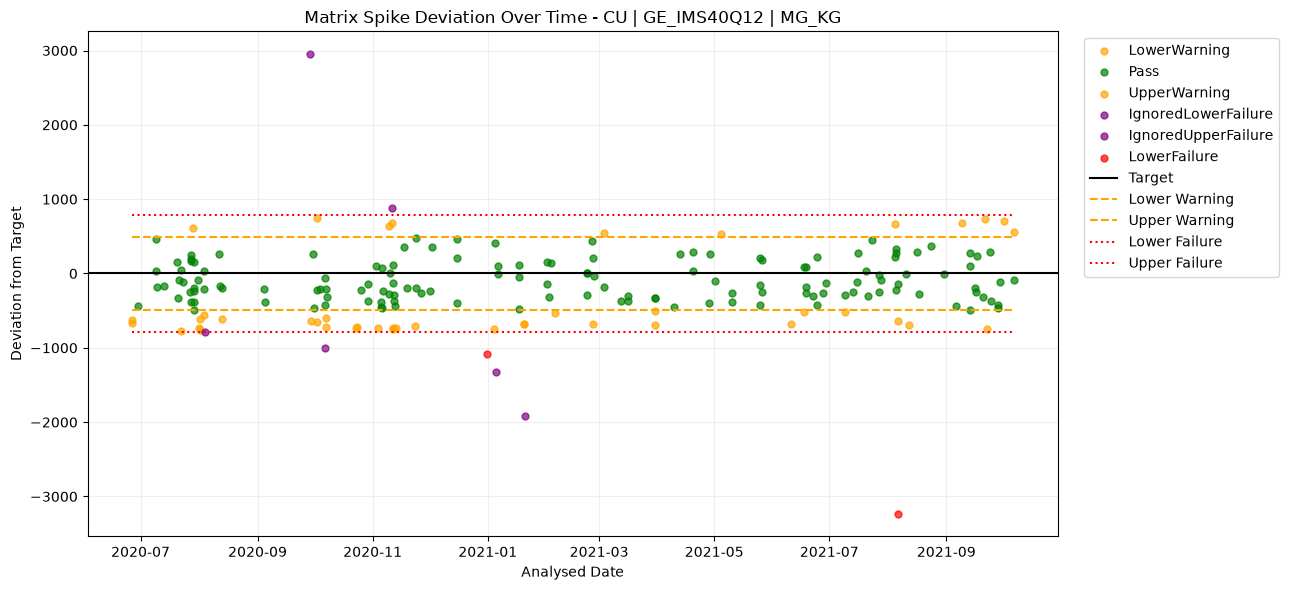

In [30]:
group_counts = (
    ms_time
    .groupby(
        ["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]
    )
    .size()
    .reset_index(name="Records")
    .sort_values("Records", ascending=False)
)

for _, row in group_counts.head(10).iterrows():

    plot_ms_deviation(
        ms_time,
        row["SCHEME_CODE"],
        row["ANALYTE_CODE"],
        row["UNIT_CODE"]
    )

## 7. Time-Series Findings

The Matrix Spike time-series visualisations show that historical behaviour
differs between analytes.

Most analytes have the majority of results relatively close to their supplied
target, but the amount of variation differs between analytes.

Some analytes, such as SE, show relatively tight historical behaviour, while
others, such as MO and CU, show much wider historical variation and occasional
large departures from the target.

Existing CCLAS Warning, Failure and IgnoredFailure classifications occur at
different points throughout the historical period.

The plots do not show one consistent drift pattern across all analytes.
Instead, they establish the historical behaviour of each analyte before formal
drift detection is applied.

No new anomaly or drift classifications are created in this notebook.

## 8. Conclusion

This notebook establishes historical Matrix Spike behaviour through
per-analyte time-series visualisation.

By plotting deviation from the supplied target and overlaying the existing
CCLAS warning and failure limits, the analysis shows how each analyte has
behaved historically and where existing QC issues have occurred.

The results provide the historical context required for the next task:
formal Matrix Spike drift detection.